# Superposition & the anatomy of a sparse autoencoder

*Part 1 of a 4-part speedrun on sparse autoencoders (SAEs) — everything you need to
reconstruct a [Neuronpedia](https://www.neuronpedia.org) feature dashboard from scratch,
and to train your own SAE on Gemma 3.*

*(New to autoencoders? Start with the [Part 0 primer](00_autoencoders_from_scratch.ipynb):
linear autoencoders = PCA, how a ReLU enables superposition, and why an SAE runs the whole
process in reverse.)*

The goal of this series is a single, concrete target: the dashboard for
[**`gemma-3-1b / layer-13 / gemmascope-2-res-16k / latent 7447`**](https://www.neuronpedia.org/gemma-3-1b/13-gemmascope-2-res-16k/7447)
— which, as we'll discover in Part 3, is a **"fruit" feature**. By the end you'll know
what every panel on that page means, how it's computed, and how the SAE behind it was built.

This first notebook answers the two questions everything else rests on:

1. **Why do we need SAEs at all?** → *superposition*: neural networks pack more features
   than they have neurons, so individual neurons are not the right unit of analysis.
2. **What is an SAE, mechanically?** → an overcomplete dictionary trained to
   *reconstruct* activations while keeping only a *sparse* set of latents active.

Everything here runs on CPU in a few seconds — we use tiny toy models so the ground truth
is known and every claim is checkable. The real Gemma 3 work starts in Part 3.


## 1. Features, and the linear representation hypothesis

A **feature** is a property of the input that a model has learned to represent — "this text
is in French", "the current token is a fruit", "we're inside a parenthetical". The
**linear representation hypothesis** says these features are encoded as **directions** in a
model's activation space: feature $i$ has some unit vector $\mathbf{d}_i \in \mathbb{R}^{d}$,
and the activation vector for a given token is (approximately) a sparse weighted sum

$$\mathbf{x} \;\approx\; \mathbf{b} + \sum_i a_i\, \mathbf{d}_i,\qquad a_i \ge 0,\ \text{most } a_i = 0.$$

The scalar $a_i$ is *how strongly* feature $i$ is present. If this picture is right, then
understanding a model means finding the dictionary $\{\mathbf{d}_i\}$ and reading off which
features fire where. That is *exactly* what an SAE tries to do.

The catch: the model's natural basis — its individual neurons — is **not** the dictionary.
A single neuron typically responds to many unrelated features (it is *polysemantic*), and a
single feature is typically spread across many neurons. The reason is **superposition**.


## 2. Superposition: more features than dimensions

Suppose a model would "like" to represent $m$ features but only has $d < m$ dimensions to
store them in. It cannot give every feature its own orthogonal axis. But if features are
**sparse** (rarely active) and the model tolerates a little interference, it can do
something clever: store the features as $m$ *non-orthogonal* directions crammed into $d$
dimensions. When only a few features are active at once, the interference between them is
usually small enough to recover the signal.

The classic demonstration (Anthropic's *Toy Models of Superposition*) is a tiny autoencoder
that is *forced* to compress $m$ sparse features through a $d$-dimensional bottleneck:

$$\mathbf{h} = W\mathbf{x}\ \ (\text{compress to } d),\qquad
  \hat{\mathbf{x}} = \operatorname{ReLU}(W^\top \mathbf{h} + \mathbf{b})\ \ (\text{decompress}).$$

$W$ is $d \times m$. The columns of $W$ are the directions the model chooses for each feature.
Let's train it with $m=5$ features squeezed into $d=2$ dimensions and look at the geometry.


```{raw} html
<figure style="margin:1.6rem auto;text-align:center;max-width:720px">
<svg viewBox="0 0 680 312" role="img" xmlns="http://www.w3.org/2000/svg" style="width:100%;height:auto;overflow:visible" font-family="system-ui,-apple-system,Segoe UI,sans-serif">
<text x="340" y="26" text-anchor="middle" font-size="15" font-weight="600" fill="currentColor">Undercomplete autoencoder — a d-dim bottleneck (d &lt; m) forces superposition</text>
<line x1="134" y1="70" x2="323" y2="133" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="134" y1="70" x2="323" y2="175" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="134" y1="112" x2="323" y2="133" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="134" y1="112" x2="323" y2="175" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="134" y1="154" x2="323" y2="133" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="134" y1="154" x2="323" y2="175" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="134" y1="196" x2="323" y2="133" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="134" y1="196" x2="323" y2="175" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="134" y1="238" x2="323" y2="133" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="134" y1="238" x2="323" y2="175" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="357" y1="133" x2="546" y2="70" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="357" y1="133" x2="546" y2="112" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="357" y1="133" x2="546" y2="154" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="357" y1="133" x2="546" y2="196" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="357" y1="133" x2="546" y2="238" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="357" y1="175" x2="546" y2="70" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="357" y1="175" x2="546" y2="112" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="357" y1="175" x2="546" y2="154" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="357" y1="175" x2="546" y2="196" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="357" y1="175" x2="546" y2="238" stroke="currentColor" stroke-opacity="0.16"/>
<circle cx="120" cy="70" r="13" fill="#f08c00"/>
<circle cx="120" cy="112" r="13" fill="none" stroke="currentColor" stroke-opacity="0.55"/>
<circle cx="120" cy="154" r="13" fill="none" stroke="currentColor" stroke-opacity="0.55"/>
<circle cx="120" cy="196" r="13" fill="#f08c00"/>
<circle cx="120" cy="238" r="13" fill="none" stroke="currentColor" stroke-opacity="0.55"/>
<circle cx="340" cy="133" r="16" fill="#4c8dd6"/>
<circle cx="340" cy="175" r="16" fill="#4c8dd6"/>
<circle cx="560" cy="70" r="13" fill="none" stroke="currentColor" stroke-opacity="0.55"/>
<circle cx="560" cy="112" r="13" fill="none" stroke="currentColor" stroke-opacity="0.55"/>
<circle cx="560" cy="154" r="13" fill="none" stroke="currentColor" stroke-opacity="0.55"/>
<circle cx="560" cy="196" r="13" fill="none" stroke="currentColor" stroke-opacity="0.55"/>
<circle cx="560" cy="238" r="13" fill="none" stroke="currentColor" stroke-opacity="0.55"/>
<text x="120" y="282" text-anchor="middle" font-size="14" fill="currentColor">features  x  (m = 5)</text>
<text x="340" y="282" text-anchor="middle" font-size="14" fill="currentColor">h = Wx  (d = 2)</text>
<text x="340" y="300" text-anchor="middle" font-size="12" fill="currentColor" opacity="0.65">bottleneck</text>
<text x="560" y="282" text-anchor="middle" font-size="14" fill="currentColor">x̂ = ReLU(Wᵀh + b)</text>
</svg>
<figcaption style="font-size:0.9em;opacity:0.72;margin-top:0.5rem">The toy model of §2. Five sparse features are squeezed through two hidden units and reconstructed. Because <em>d</em>&nbsp;&lt;&nbsp;<em>m</em>, the features cannot be orthogonal — they share the two dimensions (superposition). Orange = an active feature; the encoder and decoder both reuse the same weight matrix <em>W</em>.</figcaption>
</figure>
```


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)

class ToyModel(nn.Module):
    def __init__(self, n_features, n_hidden):
        super().__init__()
        self.W = nn.Parameter(torch.empty(n_hidden, n_features))
        nn.init.xavier_normal_(self.W)
        self.b = nn.Parameter(torch.zeros(n_features))
    def forward(self, x):
        h = x @ self.W.T                      # compress:  (batch, n_hidden)
        return F.relu(h @ self.W + self.b)    # decompress: (batch, n_features)

def generate_batch(batch, n_features, S):
    """Synthetic *sparse* feature vectors — the data the toy model must represent.

    Each of the `n_features` coordinates is, independently:
      - ON with probability `S`  (so on average only S·n_features fire at once), and
      - when ON, a random magnitude in (0, 1); when OFF, exactly 0.
    `S` is the key knob: the sparser the features, the more of them a d-dim
    bottleneck can pack into superposition without the interference swamping them.
    """
    is_on     = torch.rand(batch, n_features) < S   # e.g. [[False, False,  True, False, False]]
    magnitude = torch.rand(batch, n_features)        # e.g. [[0.549, 0.715, 0.603, 0.545, 0.424]]
    return magnitude * is_on                          # e.g. [[0.000, 0.000, 0.603, 0.000, 0.000]]

def train_toy(n_features, n_hidden, S, steps=6000, batch=1024, lr=1e-2):
    # Objective: plain reconstruction error (MSE). It's an autoencoder, so we simply ask
    # the output to match the input — no labels needed (exactly what an SAE does too).
    # Under the d < m bottleneck, minimising this is what forces superposition: the model
    # packs the sparse features into shared directions because, when they rarely collide,
    # that reconstructs them better on average than giving up and dropping them.
    model = ToyModel(n_features, n_hidden)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(steps):
        x = generate_batch(batch, n_features, S)
        loss = ((x - model(x)) ** 2).mean()
        opt.zero_grad(); loss.backward(); opt.step()
    return model

# 5 features, 2 hidden dims, high sparsity (each feature ON ~5% of the time)
model2d = train_toy(n_features=5, n_hidden=2, S=0.05)
W = model2d.W.detach()
print("feature vector norms:", W.norm(dim=0).numpy().round(2))


feature vector norms: [1.15 1.14 1.13 1.12 1.12]


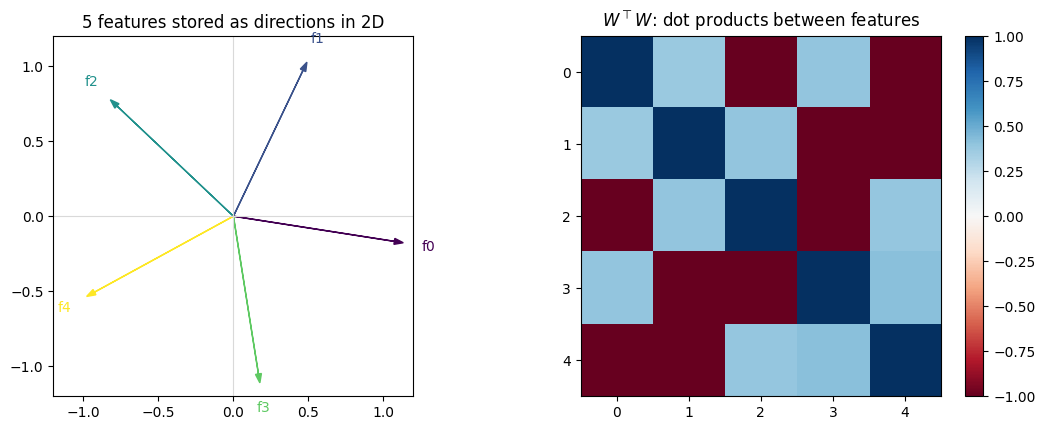

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))

# (a) the 5 feature directions as 2D vectors
colors = plt.cm.viridis(np.linspace(0, 1, 5))
for i in range(5):
    ax[0].arrow(0, 0, W[0, i], W[1, i], head_width=0.04, color=colors[i], length_includes_head=True)
    ax[0].text(W[0, i]*1.15, W[1, i]*1.15, f"f{i}", color=colors[i], ha="center", va="center")
lim = 1.2
ax[0].set_xlim(-lim, lim); ax[0].set_ylim(-lim, lim); ax[0].set_aspect("equal")
ax[0].axhline(0, color="0.85", lw=.8); ax[0].axvline(0, color="0.85", lw=.8)
ax[0].set_title("5 features stored as directions in 2D")

# (b) the interference matrix WᵀW  (off-diagonal = feature overlap)
im = ax[1].imshow(W.T @ W, cmap="RdBu", vmin=-1, vmax=1)
ax[1].set_title(r"$W^\top W$: dot products between features")
ax[1].set_xticks(range(5)); ax[1].set_yticks(range(5))
plt.colorbar(im, ax=ax[1], fraction=0.046)
plt.tight_layout(); plt.show()


The model arranges the five features as spokes of a **pentagon** (or a similar symmetric
arrangement). It cannot make them orthogonal — there are only two dimensions — so it spreads
them out to *minimise interference*: the off-diagonal entries of $W^\top W$ are small but
non-zero. This is superposition in miniature. Two consequences that matter for the rest of
the series:

- **Each axis (neuron) is polysemantic.** The x-axis has non-zero projection from several
  features at once. Reading neuron 0 tells you about a blend of features, not one.
- **Sparsity is what makes it work.** If many features were on simultaneously, the
  interference would swamp the signal. The sparser the features, the more you can pack in.
  (Try re-running with `S=0.3` — the geometry collapses toward storing just two of the
  features orthogonally (which two is arbitrary), because interference is no longer affordable.)

Real language-model activations are the same story with $d$ in the thousands and the number
of features plausibly in the *hundreds of thousands*. We can't read features off neurons.
We need to *learn the dictionary*. Enter the SAE.


## 3. The sparse autoencoder

An SAE is a second, wider autoencoder that we bolt onto a *frozen* model's activations. It
does not change the model; it just learns to re-express each activation vector $\mathbf{x}$
as a sparse combination of dictionary directions. The architecture:

$$
\begin{aligned}
\text{encode:}\quad \mathbf{f} &= \sigma\!\big(W_{\text{enc}}(\mathbf{x}-\mathbf{b}_{\text{dec}}) + \mathbf{b}_{\text{enc}}\big) \\
\text{decode:}\quad \hat{\mathbf{x}} &= \mathbf{b}_{\text{dec}} + \sum_i f_i\, \mathbf{d}_i \quad(\mathbf{d}_i = \text{row } i \text{ of } W_{\text{dec}})
\end{aligned}
$$

- $\mathbf{x} \in \mathbb{R}^{d_{\text{model}}}$ is one activation vector (e.g. a residual-stream
  vector at some layer and token).
- $\mathbf{f} \in \mathbb{R}^{d_{\text{sae}}}$ are the **latents** (a.k.a. features), with
  $d_{\text{sae}} \gg d_{\text{model}}$ — the dictionary is **overcomplete**. GemmaScope uses
  $d_{\text{model}}=1152$ and $d_{\text{sae}}=16384$ (a 14× expansion).
- The **rows of $W_{\text{dec}}$** are the dictionary directions $\mathbf{d}_i$. They're held to
  **unit norm**, so all the "how strongly is this feature present" information lives in
  $\mathbf{f}$, not in the vector lengths.
- $\sigma$ keeps latents **non-negative** — ReLU to start, JumpReLU in Part 2 — so they can sit at
  exactly zero. The *sparsity* itself comes from the loss below, not from $\sigma$.
- $\mathbf{b}_{\text{dec}}$ is subtracted before encoding and added back after — it acts as a
  learned "center" for the activations.

We train it on a single objective: **reconstruct $\mathbf{x}$ using as few active latents as
possible.**


```{raw} html
<figure style="margin:1.6rem auto;text-align:center;max-width:720px">
<svg viewBox="0 0 680 384" role="img" xmlns="http://www.w3.org/2000/svg" style="width:100%;height:auto;overflow:visible" font-family="system-ui,-apple-system,Segoe UI,sans-serif">
<text x="340" y="24" text-anchor="middle" font-size="15" font-weight="600" fill="currentColor">Sparse autoencoder — an overcomplete dictionary where only a few latents fire</text>
<line x1="123" y1="95" x2="336" y2="40" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="95" x2="336" y2="71" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="95" x2="336" y2="102" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="95" x2="336" y2="133" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="95" x2="336" y2="164" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="95" x2="336" y2="195" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="95" x2="336" y2="226" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="95" x2="336" y2="257" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="95" x2="336" y2="288" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="95" x2="336" y2="319" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="150" x2="336" y2="40" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="150" x2="336" y2="71" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="150" x2="336" y2="102" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="150" x2="336" y2="133" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="150" x2="336" y2="164" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="150" x2="336" y2="195" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="150" x2="336" y2="226" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="150" x2="336" y2="257" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="150" x2="336" y2="288" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="150" x2="336" y2="319" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="205" x2="336" y2="40" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="205" x2="336" y2="71" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="205" x2="336" y2="102" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="205" x2="336" y2="133" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="205" x2="336" y2="164" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="205" x2="336" y2="195" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="205" x2="336" y2="226" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="205" x2="336" y2="257" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="205" x2="336" y2="288" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="205" x2="336" y2="319" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="260" x2="336" y2="40" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="260" x2="336" y2="71" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="260" x2="336" y2="102" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="260" x2="336" y2="133" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="260" x2="336" y2="164" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="260" x2="336" y2="195" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="260" x2="336" y2="226" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="260" x2="336" y2="257" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="260" x2="336" y2="288" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="123" y1="260" x2="336" y2="319" stroke="currentColor" stroke-opacity="0.10"/>
<line x1="356" y1="288" x2="562" y2="95" stroke="#f08c00" stroke-opacity="0.55" stroke-width="2"/>
<line x1="356" y1="288" x2="562" y2="150" stroke="#f08c00" stroke-opacity="0.55" stroke-width="2"/>
<line x1="356" y1="288" x2="562" y2="205" stroke="#f08c00" stroke-opacity="0.55" stroke-width="2"/>
<line x1="356" y1="288" x2="562" y2="260" stroke="#f08c00" stroke-opacity="0.55" stroke-width="2"/>
<line x1="356" y1="102" x2="562" y2="95" stroke="#f08c00" stroke-opacity="0.55" stroke-width="2"/>
<line x1="356" y1="102" x2="562" y2="150" stroke="#f08c00" stroke-opacity="0.55" stroke-width="2"/>
<line x1="356" y1="102" x2="562" y2="205" stroke="#f08c00" stroke-opacity="0.55" stroke-width="2"/>
<line x1="356" y1="102" x2="562" y2="260" stroke="#f08c00" stroke-opacity="0.55" stroke-width="2"/>
<line x1="356" y1="195" x2="562" y2="95" stroke="#f08c00" stroke-opacity="0.55" stroke-width="2"/>
<line x1="356" y1="195" x2="562" y2="150" stroke="#f08c00" stroke-opacity="0.55" stroke-width="2"/>
<line x1="356" y1="195" x2="562" y2="205" stroke="#f08c00" stroke-opacity="0.55" stroke-width="2"/>
<line x1="356" y1="195" x2="562" y2="260" stroke="#f08c00" stroke-opacity="0.55" stroke-width="2"/>
<circle cx="110" cy="95" r="13" fill="#4c8dd6"/>
<circle cx="110" cy="150" r="13" fill="#4c8dd6"/>
<circle cx="110" cy="205" r="13" fill="#4c8dd6"/>
<circle cx="110" cy="260" r="13" fill="#4c8dd6"/>
<circle cx="345" cy="40" r="7" fill="none" stroke="currentColor" stroke-opacity="0.4"/>
<circle cx="345" cy="71" r="7" fill="none" stroke="currentColor" stroke-opacity="0.4"/>
<circle cx="345" cy="102" r="11" fill="#f08c00"/>
<circle cx="345" cy="133" r="7" fill="none" stroke="currentColor" stroke-opacity="0.4"/>
<circle cx="345" cy="164" r="7" fill="none" stroke="currentColor" stroke-opacity="0.4"/>
<circle cx="345" cy="195" r="11" fill="#f08c00"/>
<circle cx="345" cy="226" r="7" fill="none" stroke="currentColor" stroke-opacity="0.4"/>
<circle cx="345" cy="257" r="7" fill="none" stroke="currentColor" stroke-opacity="0.4"/>
<circle cx="345" cy="288" r="11" fill="#f08c00"/>
<circle cx="345" cy="319" r="7" fill="none" stroke="currentColor" stroke-opacity="0.4"/>
<circle cx="575" cy="95" r="13" fill="none" stroke="currentColor" stroke-opacity="0.55"/>
<circle cx="575" cy="150" r="13" fill="none" stroke="currentColor" stroke-opacity="0.55"/>
<circle cx="575" cy="205" r="13" fill="none" stroke="currentColor" stroke-opacity="0.55"/>
<circle cx="575" cy="260" r="13" fill="none" stroke="currentColor" stroke-opacity="0.55"/>
<text x="110" y="305" text-anchor="middle" font-size="14" fill="currentColor">activation  x</text>
<text x="110" y="323" text-anchor="middle" font-size="12" fill="currentColor" opacity="0.65">d_model = 4</text>
<text x="345" y="352" text-anchor="middle" font-size="14" fill="currentColor">latents  f</text>
<text x="345" y="370" text-anchor="middle" font-size="12" fill="currentColor" opacity="0.65">d_sae ≫ d_model · sparse</text>
<text x="575" y="305" text-anchor="middle" font-size="14" fill="currentColor">x̂ = b + Σ fᵢ dᵢ</text>
<text x="575" y="323" text-anchor="middle" font-size="12" fill="currentColor" opacity="0.65">from a few atoms</text>
<circle cx="500" cy="52" r="6" fill="#f08c00"/><text x="512" y="56" font-size="12" fill="currentColor">active latent</text>
<circle cx="500" cy="72" r="5" fill="none" stroke="currentColor" stroke-opacity="0.4"/><text x="512" y="76" font-size="12" fill="currentColor" opacity="0.75">inactive</text>
</svg>
<figcaption style="font-size:0.9em;opacity:0.72;margin-top:0.5rem">The SAE of §3. The dictionary is <em>overcomplete</em> (d_sae&nbsp;≫&nbsp;d_model), so the encoder fans a 4-dim activation out to many latents — but only a handful are non-zero (orange). Reconstruction is the sum of just those few decoder directions (the bold orange edges), which is why <em>x̂ = b + Σ fᵢ dᵢ</em> stays sparse.</figcaption>
</figure>
```


### The loss: reconstruction + sparsity

$$
\mathcal{L}(\mathbf{x}) \;=\; \underbrace{\lVert \mathbf{x}-\hat{\mathbf{x}}\rVert_2^2}_{\text{reconstruction}}
\;+\; \underbrace{\lambda\, \lVert \mathbf{f}\rVert_1}_{\text{sparsity}}.
$$

The reconstruction term wants $\hat{\mathbf{x}}$ to match $\mathbf{x}$. Left alone it would just
use all the latents. The sparsity term fights back: the **$L_1$ penalty** $\sum_i |f_i|$ pushes
activations toward zero, and because the $L_1$ ball has corners, the minimum tends to land on
solutions where *most* $f_i$ are **exactly** zero. The coefficient $\lambda$ sets the trade-off.

Why $L_1$ and not "count the non-zeros"? Because the thing we actually care about is the
**$L_0$ "norm"** — the *number* of active latents:

$$\lVert \mathbf{f}\rVert_0 \;=\; \#\{i : f_i \neq 0\}.$$

$L_0$ is exactly "how many features fired", which is what interpretability cares about — but
it's piecewise-constant, so its gradient is zero almost everywhere and useless for training.
$L_1$ is the convex surrogate whose gradient is non-zero almost everywhere and *does* induce sparsity. This gap
between "the $L_0$ we want" and "the $L_1$ we can optimise" is the single most important
tension in SAE design, and it's what motivates JumpReLU in Part 2. **Remember the phrase
"L0" — on the Neuronpedia dashboard it's the average number of latents active per token, and
it's the headline number for how interpretable an SAE is.**


## 4. Watching an SAE recover features from superposition

To *prove* the SAE does what we claim, we need ground truth, so we generate activations from a
**known** dictionary (these activations play the role of the toy model's bottleneck $\mathbf{h}$
from §2 — the compressed vector an SAE actually sees).

Setup: $n_{\text{true}}=32$ ground-truth feature directions in a $d=16$-dim space (genuinely in
superposition, $32 > 16$). Each data point turns on ~3 random features with known positive
magnitudes and sums their directions — precisely the generative model the SAE assumes, so a good
SAE should rediscover the 32.


In [3]:
torch.manual_seed(0)
d, n_true, d_sae = 16, 32, 64
D_true = F.normalize(torch.randn(n_true, d), dim=-1)   # ground-truth dictionary (unit rows)
p_active = 3.0 / n_true                                 # ~3 active features per example

def gen(batch):
    mask = (torch.rand(batch, n_true) < p_active).float()
    mags = (0.5 + torch.rand(batch, n_true)) * mask     # magnitude ~ U(0.5, 1.5) when ON
    return mags @ D_true, mags                          # x = sum of active feature directions

class ReLUSAE(nn.Module):
    def __init__(self, d_model, d_sae):
        super().__init__()
        self.b_dec = nn.Parameter(torch.zeros(d_model))
        self.W_enc = nn.Parameter(torch.randn(d_model, d_sae) / np.sqrt(d_model))
        self.b_enc = nn.Parameter(torch.zeros(d_sae))
        self.W_dec = nn.Parameter(F.normalize(torch.randn(d_sae, d_model), dim=-1))
    @torch.no_grad()
    def normalize_decoder(self):
        self.W_dec.data = F.normalize(self.W_dec.data, dim=-1)
    def forward(self, x):
        f = F.relu((x - self.b_dec) @ self.W_enc + self.b_enc)   # encode (ReLU)
        return f @ self.W_dec + self.b_dec, f                    # decode

def train_relu_sae(sae, l1=0.4, steps=2000, batch=4096, lr=4e-3):
    opt = torch.optim.Adam(sae.parameters(), lr=lr)
    for _ in range(steps):
        x, _ = gen(batch)
        x_hat, f = sae(x)
        loss = ((x_hat - x) ** 2).sum(-1).mean() + l1 * f.abs().sum(-1).mean()
        opt.zero_grad(); loss.backward(); opt.step()
        sae.normalize_decoder()          # keep dictionary directions unit-norm
    return sae

sae = train_relu_sae(ReLUSAE(d, d_sae))

# how many active latents per example (L0), and reconstruction quality (FVU)?
x, mags = gen(8192)
x_hat, f = sae(x)
L0  = (f > 1e-6).float().sum(-1).mean().item()
FVU = (((x_hat - x) ** 2).sum() / ((x - x.mean(0)) ** 2).sum()).item()
print(f"L0 (avg active latents) = {L0:.2f}   (true value ~ {p_active*n_true:.1f})")
print(f"FVU (fraction of variance unexplained) = {FVU:.3f}   ->  {1-FVU:.1%} of variance explained")


L0 (avg active latents) = 8.71   (true value ~ 3.0)
FVU (fraction of variance unexplained) = 0.125   ->  87.5% of variance explained


72% of the 32 true features recovered with cosine > 0.9


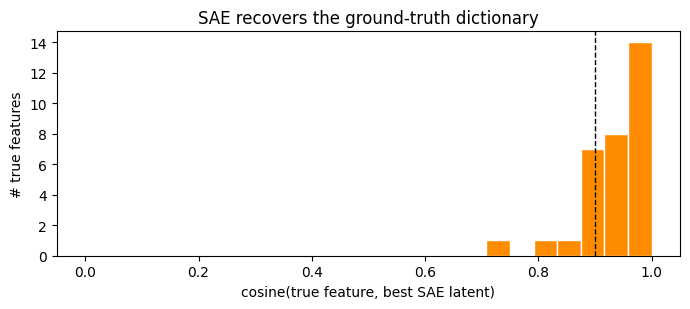

In [4]:
# Did we recover the true dictionary? Match each true feature to its best SAE latent by cosine.
cos = F.normalize(D_true, dim=-1) @ F.normalize(sae.W_dec.detach(), dim=-1).T   # (n_true, d_sae)
best_cos = cos.max(dim=1).values
recovered = (best_cos > 0.9).float().mean().item()
print(f"{recovered:.0%} of the {n_true} true features recovered with cosine > 0.9")

plt.figure(figsize=(7, 3.2))
plt.hist(best_cos.numpy(), bins=24, range=(0, 1), color="darkorange", edgecolor="white")
plt.axvline(0.9, color="k", ls="--", lw=1); plt.xlabel("cosine(true feature, best SAE latent)")
plt.ylabel("# true features"); plt.title("SAE recovers the ground-truth dictionary")
plt.tight_layout(); plt.show()


Most of the true directions come back with cosine ≈ 1 — the SAE has **un-mixed the
superposition**, turning polysemantic 16-dimensional vectors into a mostly-monosemantic
64-latent code, using only ~3 latents per example. That's the whole game.

Two things to notice, because they're the seeds of Part 2:

- **L0 is measured, not set.** We chose $\lambda$ (the $L_1$ coefficient) and *observed* an
  L0 of ~3. To hit a *target* L0 you have to hunt for the right $\lambda$. JumpReLU will let
  us target L0 more directly.
- **Not every true feature is recovered perfectly**, and some SAE latents are duplicates or
  dead. Both are real failure modes we'll meet again.


## 5. The metrics that grade an SAE

Three numbers summarise any SAE, and you'll see all three throughout the series:

| Metric | Definition | What it tells you |
|---|---|---|
| **L0** | avg. number of latents active per token, $\mathbb{E}\lVert\mathbf{f}\rVert_0$ | sparsity / interpretability. Lower = each token explained by fewer features. GemmaScope's layer-13 SAE targets **L0 ≈ 60**. |
| **Reconstruction** (FVU / variance explained) | $\mathbb{E}\lVert\mathbf{x}-\hat{\mathbf{x}}\rVert_2^2 / \mathbb{E}\lVert\mathbf{x}-\bar{\mathbf{x}}\rVert_2^2$ | fidelity. How much of the activation the SAE captures. |
| **Loss recovered** (CE / delta) | how much of the model's next-token loss survives when you *replace* $\mathbf{x}$ with $\hat{\mathbf{x}}$ | fidelity *that matters to the model* — a reconstruction can look good in MSE but still hurt the model's predictions. We'll compute this on real Gemma in Part 4. |

L0 and reconstruction are in fundamental **tension**: driving L0 down (fewer active latents)
always costs reconstruction. Every SAE lives somewhere on this Pareto frontier, and the whole
point of better architectures (Part 2) is to push the frontier outward — same reconstruction
at lower L0.

Two more diagnostics worth knowing:

- **Dead latents** — latents that (almost) never fire on any input. Wasted dictionary capacity;
  training tricks like *resampling* revive them.
- **Feature density** — for each latent, the fraction of tokens it fires on. This is literally
  the "activation density" number on the dashboard, and we'll compute it for the fruit feature
  in Part 3.


## Recap & what's next

- Models store more features than they have neurons (**superposition**), so neurons are
  polysemantic and features are directions we must *learn*.
- An **SAE** is an overcomplete autoencoder trained with **reconstruction + a sparsity penalty**;
  its decoder rows are the learned feature dictionary.
- The sparsity we *care* about is **L0** (number of active latents); the penalty we can
  *train* is **L1**. That mismatch — plus the way $L_1$ also drags down the very latents that *should* fire (**shrinkage**) — is the theme of Part 2.

**Next → Part 2: SAE architectures & JumpReLU**, where we fix L1's problems with TopK, Gated,
and the **JumpReLU** activation that GemmaScope actually uses — including implementing its
straight-through-estimator gradients by hand.
